In [1]:
import control as ctrl
import matplotlib.pyplot as plt
import math
import numpy as np

## Parte A

In [2]:
#Ej b
G = ctrl.TransferFunction([0.25], [0.003,0.0515,0.2,0.0])

gm, pm, wg, wp = ctrl.margin(G)
gm_db = 20 * math.log10(gm)

print(f"Margen de Ganancia: {gm_db:.2f} dB en w = {wg:.2f} rad/s")
print(f"Margen de Fase: {pm:.2f} grados en w = {wp:.2f} rad/s")

Margen de Ganancia: 22.76 dB en w = 8.16 rad/s
Margen de Fase: 72.22 grados en w = 1.22 rad/s


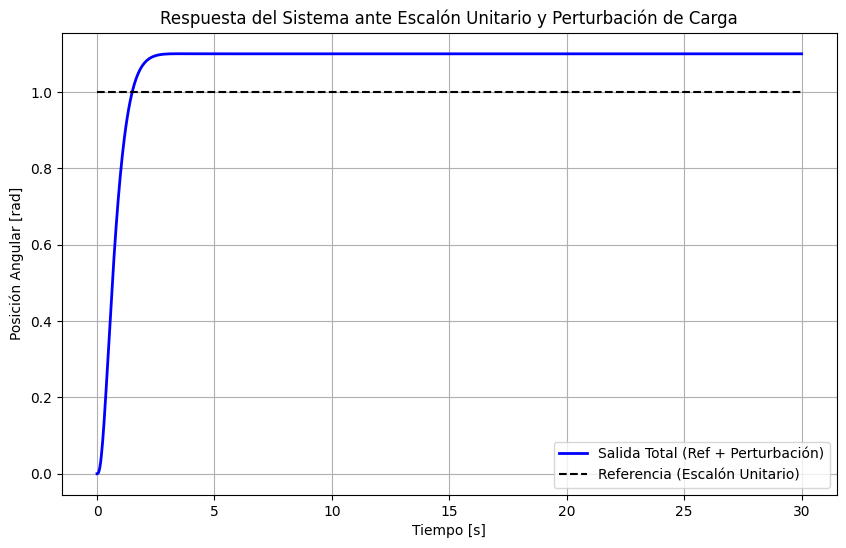

In [ ]:
#Ej c
G_ref = ctrl.tf([0.25],[0.003,0.0515,0.2,0.25])

t = np.linspace(0, 30, 1000)

t, y_ref = ctrl.step_response(G_ref, T=t)

#Agregamos la perturbacion al sistema
t, y_dist = ctrl.step_response(G_ref, T=t)
y_dist = y_dist * 0.1

y_total = y_ref + y_dist

plt.figure(figsize=(10, 6))
plt.plot(t, y_total, label='Salida Total (Ref + Perturbación)', color='blue', linewidth=2)
plt.plot(t, np.ones_like(t), label='Referencia (Escalón Unitario)', color='black', linestyle='--')


plt.title("Respuesta del Sistema ante Escalón Unitario y Perturbación de Carga")
plt.xlabel("Tiempo [s]")
plt.ylabel("Posición Angular [rad]")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

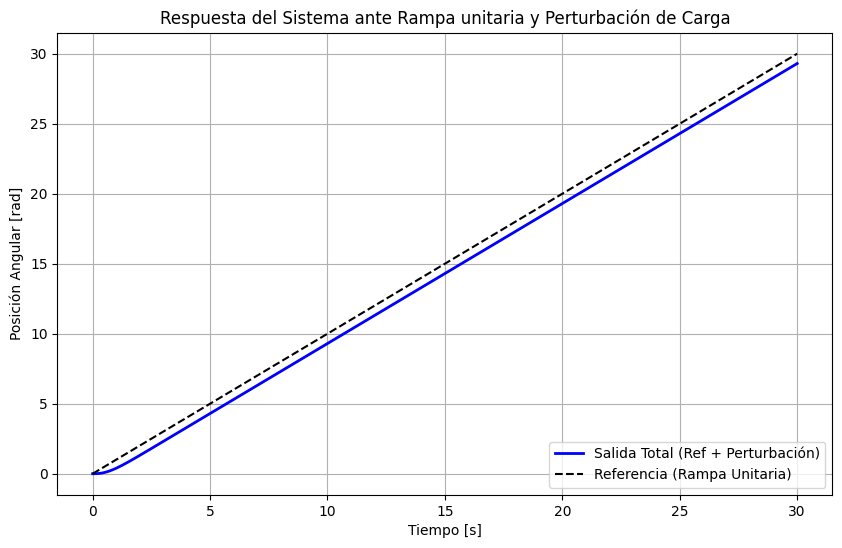

In [ ]:
#Ej d
G_ref = ctrl.tf([0.25],[0.003,0.0515,0.2,0.25])

t = np.linspace(0, 30, 1000)
t, y_ref = ctrl.forced_response(G_ref, T=t,U=t)

#Agregamos la perturbacion al sistema
t, y_dist = ctrl.step_response(G_ref, T=t)
y_dist = y_dist * 0.1

y_total = y_ref + y_dist

plt.figure(figsize=(10, 6))
plt.plot(t, y_total, label='Salida Total (Ref + Perturbación)', color='blue', linewidth=2)
plt.plot(t, t, label='Referencia (Rampa Unitaria)', color='black', linestyle='--')


plt.title("Respuesta del Sistema ante Rampa unitaria y Perturbación de Carga")
plt.xlabel("Tiempo [s]")
plt.ylabel("Posición Angular [rad]")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
